   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

Informacioni i dataset-it:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------

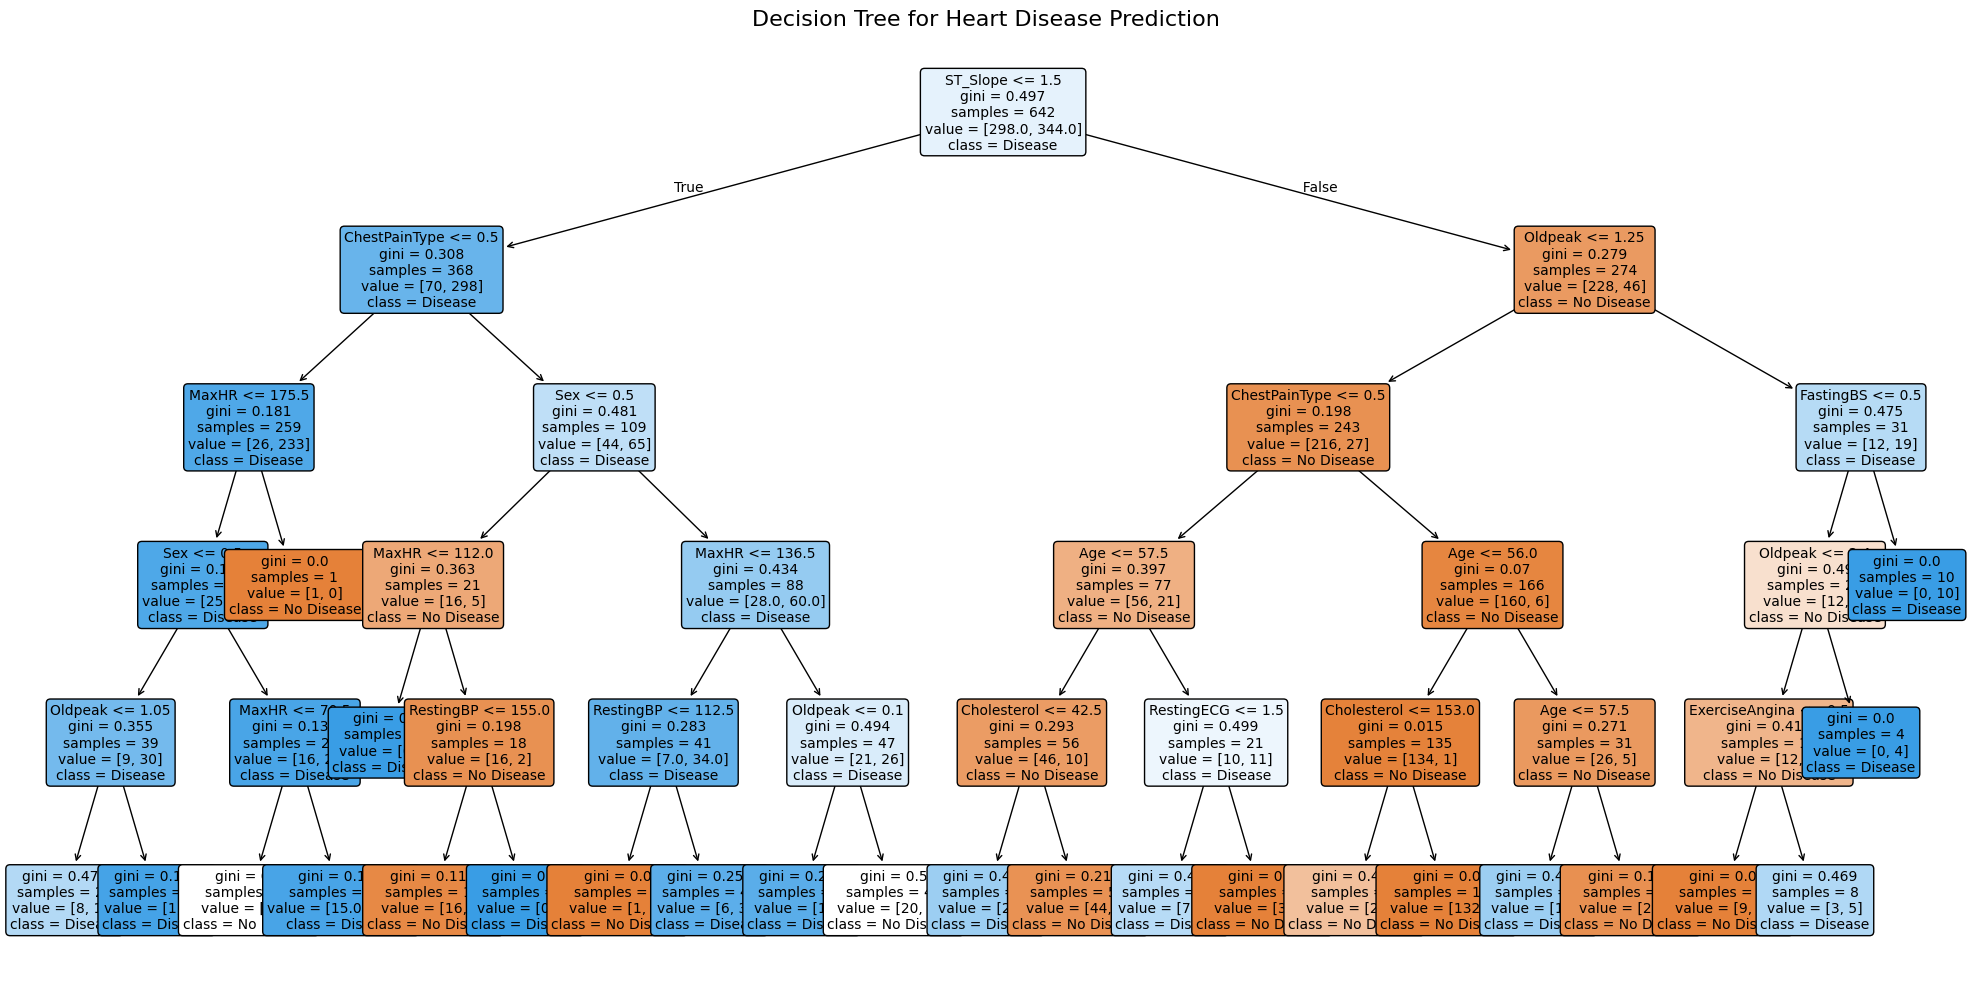


Saktësia e modelit: 0.8188
Numri i tipareve: 11
Numri i mostrave për train: 642
Numri i mostrave për test: 276


In [3]:
# Importojmë libraritë e nevojshme
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Ngarkimi i dataset-it
df = pd.read_csv('heart.csv')

# Shohim të dhënat e para
print(df.head())
print("\nInformacioni i dataset-it:")
print(df.info())

# 2. Përgatitja e të dhënave për Decision Tree
# Ndajmë tiparet (X) dhe target-in (y)
X = df.drop('HeartDisease', axis=1)  # tiparet
y = df['HeartDisease']  # target (0 ose 1)

# Konvertojmë kolonat kategorike në numerike
# Kolonat kategorike: Sex, ChestPainType, RestingECG, ExerciseAngina, ST_Slope
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

label_encoders = {}
for col in categorical_cols:
    label_encoders[col] = LabelEncoder()
    X[col] = label_encoders[col].fit_transform(X[col])

# Nuk bëjmë scaling sepse Decision Tree nuk ka nevojë për normalizim

# Ndajmë të dhënat në train dhe test (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Krijimi dhe trajnimi i Decision Tree HYPERPARAMETER
dt_classifier = DecisionTreeClassifier(random_state=42, max_depth=5)  # max_depth për pemë më të lexueshme
dt_classifier.fit(X_train, y_train)

# 4. Vizualizimi i pemës
plt.figure(figsize=(20, 10))
plot_tree(dt_classifier, 
          feature_names=X.columns, 
          class_names=['No Disease', 'Disease'],
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title("Decision Tree for Heart Disease Prediction", fontsize=16)
plt.tight_layout()
plt.show()

# Bonus: Saktësia e modelit
from sklearn.metrics import accuracy_score

y_pred = dt_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nSaktësia e modelit: {accuracy:.4f}")
print(f"Numri i tipareve: {X.shape[1]}")
print(f"Numri i mostrave për train: {X_train.shape[0]}")
print(f"Numri i mostrave për test: {X_test.shape[0]}")



In [6]:
# ============================================
# PIKA 4: LINEAR REGRESSION
# ============================================

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import numpy as np

# Shkallëzojmë të dhënat (Linear Regression ka nevojë për scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Trajnojmë modelin Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# Parashikimet
y_pred_lin = lin_reg.predict(X_test_scaled)

# Konvertimi në klasa (threshold 0.5)
y_pred_lin_class = (y_pred_lin >= 0.5).astype(int)

# Saktësia
accuracy_lin = accuracy_score(y_test, y_pred_lin_class)
mse = mean_squared_error(y_test, y_pred_lin)
r2 = r2_score(y_test, y_pred_lin)

print("="*50)
print("LINEAR REGRESSION - REZULTATET")
print("="*50)
print(f"Saktësia (accuracy): {accuracy_lin:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R²): {r2:.4f}")
print("\nKoeficientët e modelit:")
for feature, coef in zip(X.columns, lin_reg.coef_):
    print(f"  {feature}: {coef:.4f}")

LINEAR REGRESSION - REZULTATET
Saktësia (accuracy): 0.8587
Mean Squared Error (MSE): 0.1184
R-squared (R²): 0.5091

Koeficientët e modelit:
  Age: 0.0195
  Sex: 0.0600
  ChestPainType: -0.0754
  RestingBP: 0.0058
  Cholesterol: -0.0551
  FastingBS: 0.0549
  RestingECG: -0.0187
  MaxHR: -0.0298
  ExerciseAngina: 0.1045
  Oldpeak: 0.0651
  ST_Slope: -0.1449


In [7]:
# ============================================
# PIKA 5: LOGISTIC REGRESSION
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Shkallëzojmë të dhënat (edhe Logistic Regression ka nevojë për scaling)
# Përdorim të njëjtin scaler që kemi përdorur më lart
# Nëse e ekzekuton veçmas, përsërit këto rreshta:
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# Trajnojmë modelin Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Parashikimet
y_pred_log = log_reg.predict(X_test_scaled)

# Saktësia
accuracy_log = accuracy_score(y_test, y_pred_log)
conf_matrix = confusion_matrix(y_test, y_pred_log)

print("="*50)
print("LOGISTIC REGRESSION - REZULTATET")
print("="*50)
print(f"Saktësia (accuracy): {accuracy_log:.4f}")
print(f"\nMatrica e Konfuzionit:")
print("            Parashikuar")
print("           0    1")
print(f"Aktualisht 0:  {conf_matrix[0][0]:3d}   {conf_matrix[0][1]:3d}")
print(f"Aktualisht 1:  {conf_matrix[1][0]:3d}   {conf_matrix[1][1]:3d}")

print(f"\nRaporti i Klasifikimit:")
print(classification_report(y_test, y_pred_log, target_names=['No Disease', 'Disease']))

print(f"\nKoeficientët e modelit:")
for feature, coef in zip(X.columns, log_reg.coef_[0]):
    print(f"  {feature}: {coef:.4f}")

LOGISTIC REGRESSION - REZULTATET
Saktësia (accuracy): 0.8768

Matrica e Konfuzionit:
            Parashikuar
           0    1
Aktualisht 0:  100    12
Aktualisht 1:   22   142

Raporti i Klasifikimit:
              precision    recall  f1-score   support

  No Disease       0.82      0.89      0.85       112
     Disease       0.92      0.87      0.89       164

    accuracy                           0.88       276
   macro avg       0.87      0.88      0.87       276
weighted avg       0.88      0.88      0.88       276


Koeficientët e modelit:
  Age: 0.1320
  Sex: 0.4689
  ChestPainType: -0.5556
  RestingBP: 0.0419
  Cholesterol: -0.3802
  FastingBS: 0.4183
  RestingECG: -0.1471
  MaxHR: -0.1351
  ExerciseAngina: 0.5879
  Oldpeak: 0.4949
  ST_Slope: -0.9791


In [8]:
# ============================================
# PIKA 6: NAIVE BAYES
# ============================================

from sklearn.naive_bayes import GaussianNB

# Naive Bayes NUK ka nevojë për scaling, por mund të përdorim të dhënat origjinale
# Përdorim X_train dhe X_test (jo të shkallëzuara)

# Trajnojmë modelin Naive Bayes
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)

# Parashikimet
y_pred_nb = nb_classifier.predict(X_test)

# Saktësia
accuracy_nb = accuracy_score(y_test, y_pred_nb)
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)

print("="*50)
print("NAIVE BAYES - REZULTATET")
print("="*50)
print(f"Saktësia (accuracy): {accuracy_nb:.4f}")
print(f"\nMatrica e Konfuzionit:")
print("            Parashikuar")
print("           0    1")
print(f"Aktualisht 0:  {conf_matrix_nb[0][0]:3d}   {conf_matrix_nb[0][1]:3d}")
print(f"Aktualisht 1:  {conf_matrix_nb[1][0]:3d}   {conf_matrix_nb[1][1]:3d}")

print(f"\nRaporti i Klasifikimit:")
print(classification_report(y_test, y_pred_nb, target_names=['No Disease', 'Disease']))

print(f"\nProbabilitetet paraprake (Priors):")
print(f"  P(No Disease): {nb_classifier.class_prior_[0]:.4f}")
print(f"  P(Disease): {nb_classifier.class_prior_[1]:.4f}")

NAIVE BAYES - REZULTATET
Saktësia (accuracy): 0.8732

Matrica e Konfuzionit:
            Parashikuar
           0    1
Aktualisht 0:   98    14
Aktualisht 1:   21   143

Raporti i Klasifikimit:
              precision    recall  f1-score   support

  No Disease       0.82      0.88      0.85       112
     Disease       0.91      0.87      0.89       164

    accuracy                           0.87       276
   macro avg       0.87      0.87      0.87       276
weighted avg       0.88      0.87      0.87       276


Probabilitetet paraprake (Priors):
  P(No Disease): 0.4642
  P(Disease): 0.5358


TABELA KRAHASUESE E MODELEVE
              Model  Accuracy  Precision  Recall  F1-Score
      Decision Tree    0.8188     0.8904  0.7927    0.8387
  Linear Regression    0.8587     0.9195  0.8354    0.8754
Logistic Regression    0.8768     0.9221  0.8659    0.8931
        Naive Bayes    0.8732     0.9108  0.8720    0.8910

CONFUSION MATRICES PËR SECILIN MODEL

1. DECISION TREE:
            Parashikuar
           0    1
Aktualisht 0:   96    16
Aktualisht 1:   34   130

2. LINEAR REGRESSION:
            Parashikuar
           0    1
Aktualisht 0:  100    12
Aktualisht 1:   27   137

3. LOGISTIC REGRESSION:
            Parashikuar
           0    1
Aktualisht 0:  100    12
Aktualisht 1:   22   142

4. NAIVE BAYES:
            Parashikuar
           0    1
Aktualisht 0:   98    14
Aktualisht 1:   21   143


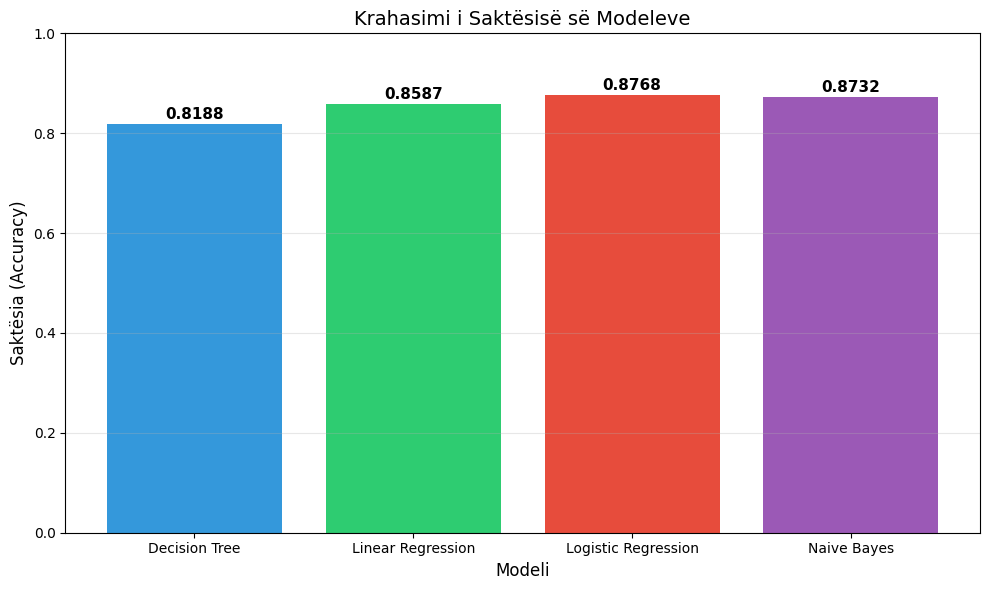

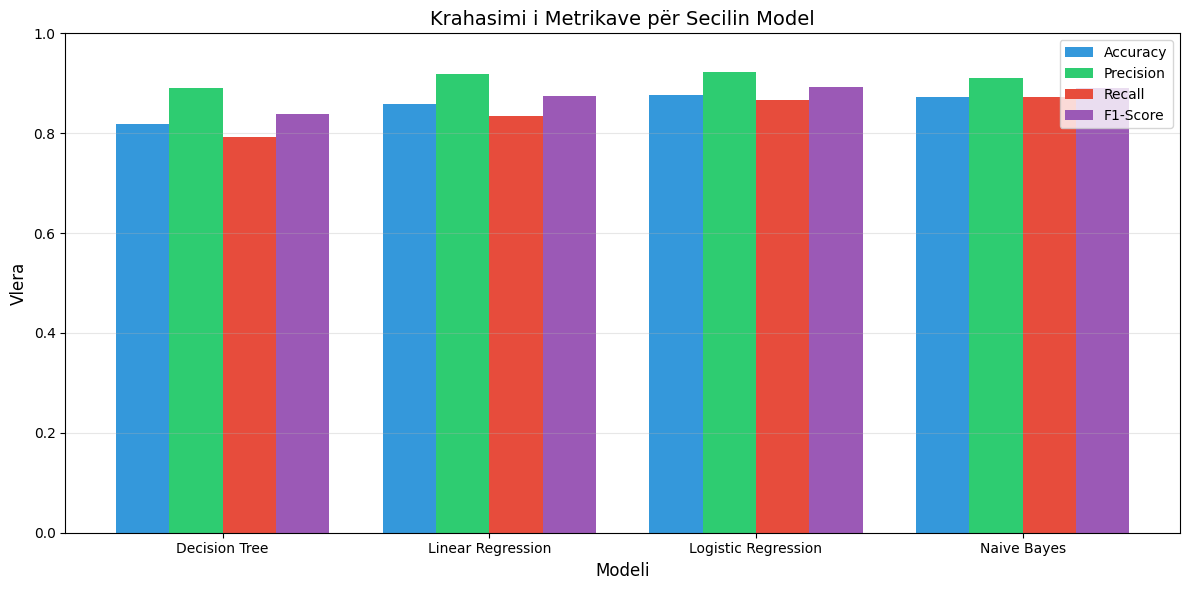

In [10]:
# ============================================
# PIKA 7: TABELA KRAHASUESE DHE CONFUSION MATRICES
# ============================================

from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Llogarisim metrikat për secilin model
# Për Decision Tree (që e ke trajnuar më herët)
y_pred_dt = dt_classifier.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
conf_dt = confusion_matrix(y_test, y_pred_dt)

# Për Linear Regression
y_pred_lin_class = (lin_reg.predict(X_test_scaled) >= 0.5).astype(int)
accuracy_lin = accuracy_score(y_test, y_pred_lin_class)
precision_lin = precision_score(y_test, y_pred_lin_class)
recall_lin = recall_score(y_test, y_pred_lin_class)
f1_lin = f1_score(y_test, y_pred_lin_class)
conf_lin = confusion_matrix(y_test, y_pred_lin_class)

# Për Logistic Regression
accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
conf_log = confusion_matrix(y_test, y_pred_log)

# Për Naive Bayes
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)
conf_nb = confusion_matrix(y_test, y_pred_nb)

# ============================================
# 1. TABELA KRAHASUESE
# ============================================
print("="*60)
print("TABELA KRAHASUESE E MODELEVE")
print("="*60)

comparison_table = pd.DataFrame({
    'Model': ['Decision Tree', 'Linear Regression', 'Logistic Regression', 'Naive Bayes'],
    'Accuracy': [accuracy_dt, accuracy_lin, accuracy_log, accuracy_nb],
    'Precision': [precision_dt, precision_lin, precision_log, precision_nb],
    'Recall': [recall_dt, recall_lin, recall_log, recall_nb],
    'F1-Score': [f1_dt, f1_lin, f1_log, f1_nb]
})

# Rrumbullakosim në 4 decimale
comparison_table = comparison_table.round(4)
print(comparison_table.to_string(index=False))

# ============================================
# 2. CONFUSION MATRICES PËR SECILIN MODEL
# ============================================
print("\n" + "="*60)
print("CONFUSION MATRICES PËR SECILIN MODEL")
print("="*60)

print("\n1. DECISION TREE:")
print("            Parashikuar")
print("           0    1")
print(f"Aktualisht 0:  {conf_dt[0][0]:3d}   {conf_dt[0][1]:3d}")
print(f"Aktualisht 1:  {conf_dt[1][0]:3d}   {conf_dt[1][1]:3d}")

print("\n2. LINEAR REGRESSION:")
print("            Parashikuar")
print("           0    1")
print(f"Aktualisht 0:  {conf_lin[0][0]:3d}   {conf_lin[0][1]:3d}")
print(f"Aktualisht 1:  {conf_lin[1][0]:3d}   {conf_lin[1][1]:3d}")

print("\n3. LOGISTIC REGRESSION:")
print("            Parashikuar")
print("           0    1")
print(f"Aktualisht 0:  {conf_log[0][0]:3d}   {conf_log[0][1]:3d}")
print(f"Aktualisht 1:  {conf_log[1][0]:3d}   {conf_log[1][1]:3d}")

print("\n4. NAIVE BAYES:")
print("            Parashikuar")
print("           0    1")
print(f"Aktualisht 0:  {conf_nb[0][0]:3d}   {conf_nb[0][1]:3d}")
print(f"Aktualisht 1:  {conf_nb[1][0]:3d}   {conf_nb[1][1]:3d}")

# ============================================
# 3. GRAFIKU KRAHASUES I SAKTËSISË
# ============================================
plt.figure(figsize=(10, 6))
models = comparison_table['Model']
accuracies = comparison_table['Accuracy']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

bars = plt.bar(models, accuracies, color=colors)
plt.xlabel('Modeli', fontsize=12)
plt.ylabel('Saktësia (Accuracy)', fontsize=12)
plt.title('Krahasimi i Saktësisë së Modeleve', fontsize=14)
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

# Shtojmë vlerat mbi secilin bar
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# 4. GRAFIKU I KRAHASIMIT TË TË GJITHA METRIKAVE
# ============================================
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(models))
width = 0.2

bars1 = ax.bar(x - 1.5*width, comparison_table['Accuracy'], width, label='Accuracy', color='#3498db')
bars2 = ax.bar(x - 0.5*width, comparison_table['Precision'], width, label='Precision', color='#2ecc71')
bars3 = ax.bar(x + 0.5*width, comparison_table['Recall'], width, label='Recall', color='#e74c3c')
bars4 = ax.bar(x + 1.5*width, comparison_table['F1-Score'], width, label='F1-Score', color='#9b59b6')

ax.set_xlabel('Modeli', fontsize=12)
ax.set_ylabel('Vlera', fontsize=12)
ax.set_title('Krahasimi i Metrikave për Secilin Model', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()